<a href="https://colab.research.google.com/github/AdiDev1411/Machine-learning/blob/main/Practical10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install opendatasets

In [3]:
import opendatasets as op
op.download('https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python?select=Mall_Customers.csv')


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: adigamer14
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python


100%|██████████| 1.55k/1.55k [00:00<00:00, 2.45MB/s]

In [4]:
import pandas as pd
import numpy as np


In [6]:
df = pd.read_csv('customer-segmentation-tutorial-in-python/Mall_Customers.csv')

In [7]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
df.drop(columns=['CustomerID'],inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [12]:
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


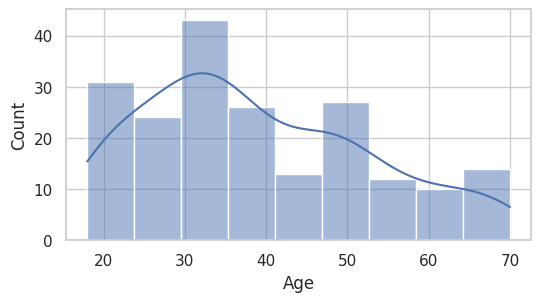

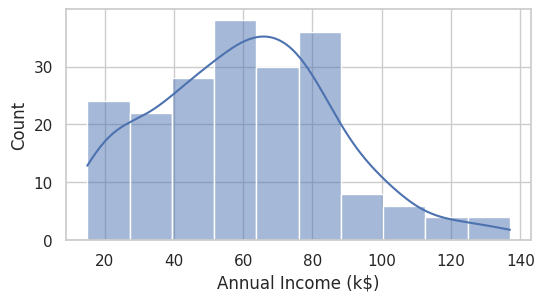

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,3))
sns.histplot(df['Age'],kde=True)
plt.show()
plt.figure(figsize=(6,3))
sns.histplot(df['Annual Income (k$)'],kde=True)
plt.show()

In [25]:
df_dummy = pd.get_dummies(df,dtype=int)

In [28]:
df_dummy.drop(columns='Gender_Female',inplace=True)

In [29]:
df_dummy

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0
...,...,...,...,...
195,35,120,79,0
196,45,126,28,0
197,32,126,74,1
198,32,137,18,1


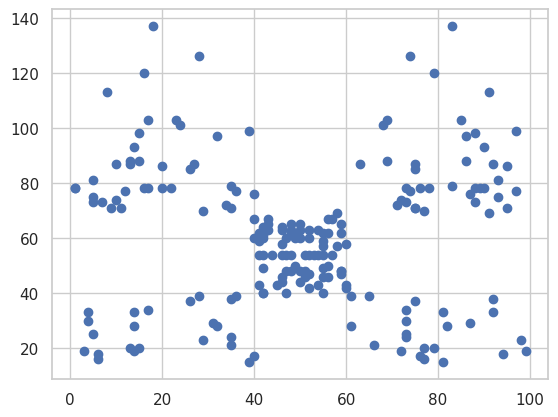

In [33]:
plt.scatter(x=df['Spending Score (1-100)'],y=df['Annual Income (k$)'])

In [34]:
from sklearn.cluster import KMeans

In [43]:
data = df_dummy[['Spending Score (1-100)', 'Annual Income (k$)']]

WCSS = []

for i in range(1,15):
  km = KMeans(n_clusters=i)
  km.fit(data)
  WCSS.append(km.inertia_)

In [62]:
data = df_dummy[['Spending Score (1-100)', 'Annual Income (k$)']]


In [44]:

WCSS

[269981.28000000014,
 183499.07470288622,
 106348.37306211119,
 73880.64496247198,
 66674.36000494969,
 37455.98455516028,
 31941.61295592704,
 26969.837587782575,
 24677.71659451658,
 21558.71576616567,
 18317.883754117986,
 17173.70962370962,
 15484.78913745713,
 13555.357782865452]

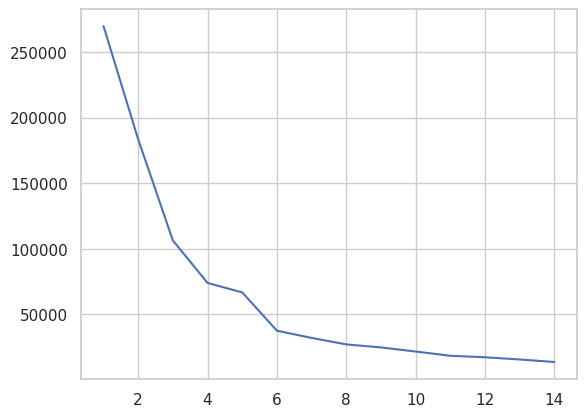

In [45]:
plt.plot(range(1,15),WCSS)


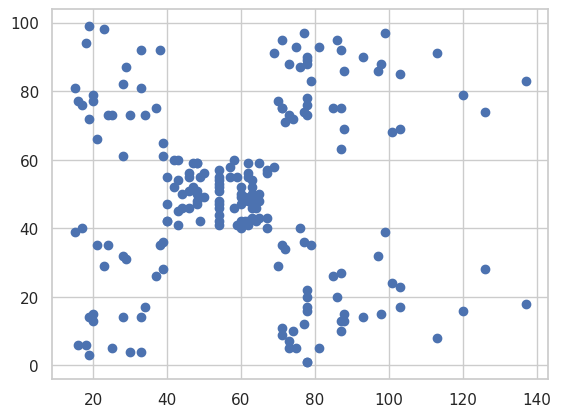

In [47]:
plt.scatter(data['Annual Income (k$)'],data['Spending Score (1-100)'])

In [51]:
X = data.iloc[:,:].values
km = KMeans(n_clusters=5)
y_means = km.fit_predict(X)

In [52]:
y_means

array([4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0,
       4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 1,
       4, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 2, 1, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 1, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

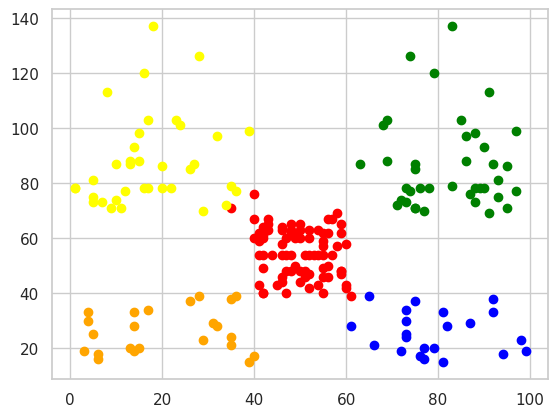

In [53]:
plt.scatter(X[y_means == 0,0] , X[y_means ==0,1] , color='blue')
plt.scatter(X[y_means == 1,0] , X[y_means ==1,1] , color='red')
plt.scatter(X[y_means == 2,0] , X[y_means ==2,1] , color='green')
plt.scatter(X[y_means == 3,0] , X[y_means ==3,1] , color='yellow')
plt.scatter(X[y_means == 4,0] , X[y_means ==4,1] , color='orange')

# DBSCAN

In [63]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


In [64]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

In [84]:
dbscan = DBSCAN(eps=0.4, min_samples=7)  # eps = neighborhood radius, min_samples = minimum points to form a cluster
labels = dbscan.fit_predict(X_scaled)


In [85]:
data['Cluster'] = labels


/tmp/ipython-input-3801890161.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cluster'] = labels


In [86]:
data

,Spending Score (1-100),Annual Income (k$),Cluster
0,39,15,1
1,81,15,1
2,6,16,0
3,77,16,1
4,40,17,1
...,...,...,...
195,79,120,-1
196,28,126,-1
197,74,126,-1
198,18,137,-1


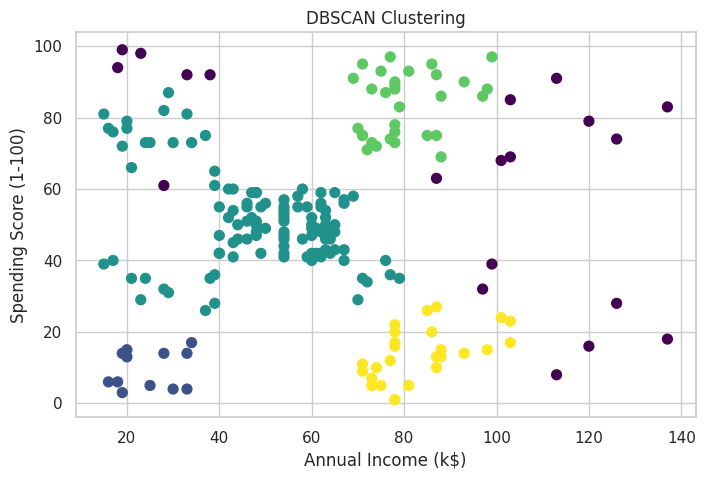

In [87]:
plt.figure(figsize=(8,5))
plt.scatter(
    data['Annual Income (k$)'],
    data['Spending Score (1-100)'],
    c=data['Cluster'], cmap='viridis', s=50
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering")
plt.show()
